<a href="https://colab.research.google.com/github/shriyyaaa/satellite-image-super-resolution-diffusion/blob/main/Eurosat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Satellite Image Super-Resolution Using Latent Diffusion**

# Technical Description
*   The project performs Super-Resolution (SR) on satellite images using a Latent Diffusion Model (LDM).
*   Images are first encoded into a latent space using a pretrained VAE encoder, reducing dimensionality while preserving structure.
*   A U-Net–based diffusion model learns to denoise latent representations and reconstruct high-frequency details.
*   During training, paired Low-Resolution (LR) and High-Resolution (HR) images are used to teach the model how to recover fine details lost in downscaling.
*   At inference, the LR image is encoded → denoised by the diffusion model → decoded back to a high-resolution output using the VAE decoder.
*   The model is optimized using MSE loss in latent space, noise-prediction loss, and optionally perceptual loss for sharper results.

# Model Flow
1.   **Data Preparation**- HR satellite images are resized to generate LR–HR pairs.
Images are normalized and converted to model-friendly format.
2.   **Encoding** - HR and LR images pass through a Variational Autoencoder (VAE) encoder to obtain latent representations.
3.   **Diffusion Process (Training)** -  Noise is added to the HR latent. The U-Net diffusion model is trained to predict and remove this noise. LR latent is used as a conditioning input to guide reconstruction.
4.   **Sampling / Inference** - Diffusion model progressively denoises the latent to approximate HR latent. VAE decoder converts the refined latent back to a high-resolution image.
5. **Output** - Final output is a super-resolved satellite image with enhanced clarity and details.

In [ ]:
import sys
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import math
from tqdm import tqdm
from einops.layers.torch import Rearrange
from datasets import load_dataset
import os
import glob

In [ ]:
import kagglehub

path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

print("Path to dataset files:", path )

Using Colab cache for faster access to the 'eurosat-dataset' dataset.
Path to dataset files: /kaggle/input/eurosat-dataset


In [ ]:
dataset = load_dataset("/kaggle/input/eurosat-dataset")["train"]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [ ]:
class EuroSAT_SR_Dataset(Dataset):
    def __init__(self, dataset, scale_factor=4, hr_size=128):
        self.data = dataset
        # self.root = "/kaggle/input/eurosat-dataset"
        self.hr_size = hr_size
        self.scale_factor = scale_factor

        self.hr_tf = transforms.Compose([
            transforms.Resize((hr_size, hr_size)),
            transforms.ToTensor(),
            transforms.Lambda(lambda t: t * 2 - 1)
        ])

        self.lr_tf = transforms.Compose([
            transforms.Resize((hr_size // scale_factor, hr_size // scale_factor)),
            transforms.Resize((hr_size, hr_size)),
            transforms.ToTensor(),
            transforms.Lambda(lambda t: t * 2 - 1)
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]

        img = sample["image"].convert("RGB")

        hr = self.hr_tf(img)
        lr = self.lr_tf(img)

        return {"lr": lr, "hr": hr}

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_channels)
        self.act1 = nn.SiLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.act2 = nn.SiLU()

        if in_channels != out_channels:
            self.res_conv = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.res_conv = nn.Identity()

    def forward(self, x):
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.act1(h)
        h = self.conv2(h)
        h = self.norm2(h)
        h = self.act2(h)

        return h + self.res_conv(x)


class UNet(nn.Module):
    def __init__(self, T, img_ch=6, out_ch=3, base_channels=128, num_res_blocks=4):
        super().__init__()
        self.T = T

        self.initial_conv = nn.Conv2d(img_ch, base_channels, 3, padding=1)
        self.res_blocks = nn.ModuleList(
            [ResidualBlock(base_channels, base_channels) for _ in range(num_res_blocks)]
        )
        self.final_conv = nn.Conv2d(base_channels, out_ch, 3, padding=1)

    def forward(self, x, t):
        # t is not used in this simplified UNet, but kept for interface consistency
        h = nn.SiLU()(self.initial_conv(x))
        for block in self.res_blocks:
            h = block(h)
        return self.final_conv(h)

In [ ]:
class DDPM:
    def __init__(self, betas, device):
        self.device = device
        self.T = len(betas)
        self.betas = betas
        self.alphas = 1 - betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)

    def q(self, x0, t):
        """
        Adds noise to image (forward diffusion)
        """
        t = t.long()
        a_bar = self.alpha_bars[t].view(-1, 1, 1, 1).to(self.device)
        noise = torch.randn_like(x0)
        x_t = torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * noise
        return x_t, noise

    def reverse_q(self, x_t, t, eps_theta):
        """
        Reverse diffusion step
        """
        t = t.long()
        beta_t = self.betas[t].view(-1, 1, 1, 1)
        alpha_t = self.alphas[t].view(-1, 1, 1, 1)
        alpha_bar_t = self.alpha_bars[t].view(-1, 1, 1, 1)

        if t[0] == 0:
            return (1 / torch.sqrt(alpha_t)) * (x_t - (beta_t / torch.sqrt(1 - alpha_bar_t)) * eps_theta)

        noise = torch.randn_like(x_t)
        return (1 / torch.sqrt(alpha_t)) * (x_t - (beta_t / torch.sqrt(1 - alpha_bar_t)) * eps_theta) + torch.sqrt(beta_t) * noise


In [ ]:
image_glob_pattern = "/kaggle/input/eurosat-dataset/EuroSAT/*/*.jpg"
found_images = glob.glob(image_glob_pattern)

print(f"Number of image files found by glob: {len(found_images)}")
if len(found_images) > 0:
    print(f"First 5 found images: {found_images[:5]}")
else:
    print("No images found with the pattern. Please check the path and file extensions.")

Number of image files found by glob: 27000
First 5 found images: ['/kaggle/input/eurosat-dataset/EuroSAT/SeaLake/SeaLake_2025.jpg', '/kaggle/input/eurosat-dataset/EuroSAT/SeaLake/SeaLake_1571.jpg', '/kaggle/input/eurosat-dataset/EuroSAT/SeaLake/SeaLake_227.jpg', '/kaggle/input/eurosat-dataset/EuroSAT/SeaLake/SeaLake_926.jpg', '/kaggle/input/eurosat-dataset/EuroSAT/SeaLake/SeaLake_907.jpg']


In [ ]:
dataset_base_path = '/kaggle/input/eurosat-dataset'

print(f"Checking existence of: {dataset_base_path}")
if os.path.exists(dataset_base_path):
    print(f"Path exists. Contents of {dataset_base_path}:")
    for item in os.listdir(dataset_base_path):
        print(f"- {item}")
else:
    print(f"Error: Path does not exist: {dataset_base_path}")


Checking existence of: /kaggle/input/eurosat-dataset
Path exists. Contents of /kaggle/input/eurosat-dataset:
- EuroSATallBands
- EuroSAT


In [ ]:
dataset_images_path = '/kaggle/input/eurosat-dataset/EuroSAT'

print(f"Checking existence of: {dataset_images_path}")
if os.path.exists(dataset_images_path):
    print(f"Path exists. Contents of {dataset_images_path} (first 10 items):")
    for i, item in enumerate(os.listdir(dataset_images_path)):
        if i >= 10: break
        print(f"- {item}")

    image_glob_pattern_jpg = f"{dataset_images_path}/*/*.jpg"
    found_images_jpg = glob.glob(image_glob_pattern_jpg)

    print(f"\nNumber of .jpg files found by glob ('{image_glob_pattern_jpg}'): {len(found_images_jpg)}")
    if len(found_images_jpg) > 0:
        print(f"First 5 .jpg images found: {found_images_jpg[:5]}")
    else:
        print("No .jpg images found with this pattern.")

    image_glob_pattern_tif = f"{dataset_images_path}/*/*.tif"
    found_images_tif = glob.glob(image_glob_pattern_tif)

    print(f"\nNumber of .tif files found by glob ('{image_glob_pattern_tif}'): {len(found_images_tif)}")
    if len(found_images_tif) > 0:
        print(f"First 5 .tif images found: {found_images_tif[:5]}")
    else:
        print("No .tif images found with this pattern.")

else:
    print(f"Error: Path does not exist: {dataset_images_path}")


Checking existence of: /kaggle/input/eurosat-dataset/EuroSAT
Path exists. Contents of /kaggle/input/eurosat-dataset/EuroSAT (first 10 items):
- SeaLake
- Highway
- River
- Pasture
- Industrial
- Residential
- PermanentCrop
- validation.csv
- AnnualCrop
- train.csv

Number of .jpg files found by glob ('/kaggle/input/eurosat-dataset/EuroSAT/*/*.jpg'): 27000
First 5 .jpg images found: ['/kaggle/input/eurosat-dataset/EuroSAT/SeaLake/SeaLake_2025.jpg', '/kaggle/input/eurosat-dataset/EuroSAT/SeaLake/SeaLake_1571.jpg', '/kaggle/input/eurosat-dataset/EuroSAT/SeaLake/SeaLake_227.jpg', '/kaggle/input/eurosat-dataset/EuroSAT/SeaLake/SeaLake_926.jpg', '/kaggle/input/eurosat-dataset/EuroSAT/SeaLake/SeaLake_907.jpg']

Number of .tif files found by glob ('/kaggle/input/eurosat-dataset/EuroSAT/*/*.tif'): 0
No .tif images found with this pattern.


In [ ]:
example_category_path = '/kaggle/input/eurosat-dataset/EuroSAT/Residential'

print(f"Contents of {example_category_path}:")
if os.path.exists(example_category_path):
    for item in os.listdir(example_category_path):
        print(f"- {item}")
else:
    print(f"Path does not exist: {example_category_path}")


Contents of /kaggle/input/eurosat-dataset/EuroSAT/Residential:
- Residential_2438.jpg
- Residential_706.jpg
- Residential_2936.jpg
- Residential_2314.jpg
- Residential_1885.jpg
- Residential_2795.jpg
- Residential_953.jpg
- Residential_2091.jpg
- Residential_2714.jpg
- Residential_1008.jpg
- Residential_1765.jpg
- Residential_1556.jpg
- Residential_1833.jpg
- Residential_2005.jpg
- Residential_587.jpg
- Residential_653.jpg
- Residential_496.jpg
- Residential_2079.jpg
- Residential_399.jpg
- Residential_2418.jpg
- Residential_2203.jpg
- Residential_498.jpg
- Residential_745.jpg
- Residential_218.jpg
- Residential_1399.jpg
- Residential_874.jpg
- Residential_2825.jpg
- Residential_2039.jpg
- Residential_890.jpg
- Residential_2041.jpg
- Residential_696.jpg
- Residential_822.jpg
- Residential_2742.jpg
- Residential_56.jpg
- Residential_1049.jpg
- Residential_1118.jpg
- Residential_581.jpg
- Residential_2534.jpg
- Residential_1655.jpg
- Residential_1445.jpg
- Residential_2861.jpg
- Resident

In [ ]:
print("Attempting to load dataset and inspect splits...")

data_files = {"train_split": "/kaggle/input/eurosat-dataset/EuroSAT/*/*.jpg"}

try:
    dataset_dict = load_dataset("imagefolder", data_files=data_files)
    print(f"Successfully loaded DatasetDict. Available splits: {dataset_dict.keys()}")

    if "train_split" in dataset_dict:
        print("\n'train_split' found. Dataset loading seems correct.")
    elif len(dataset_dict) > 0:
        first_split_name = list(dataset_dict.keys())[0]
        print(f"\n'train_split' not found, but other splits are available. Using '{first_split_name}'.")
    else:
        print("\nNo splits found in the DatasetDict. Check data_files pattern and path.")

except Exception as e:
    print(f"An error occurred during dataset loading: {e}")
    print("Please review the path and glob pattern carefully.")


Attempting to load dataset and inspect splits...


Resolving data files:   0%|          | 0/27000 [00:00<?, ?it/s]

Generating train_split split: 0 examples [00:00, ? examples/s]

Successfully loaded DatasetDict. Available splits: dict_keys(['train_split'])

'train_split' found. Dataset loading seems correct.


In [ ]:
def train_sr(epochs=5, batch_size=16, hr_size=128):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    print("Loading EuroSAT dataset...")
    data_files = {"train_split": "/kaggle/input/eurosat-dataset/EuroSAT/*/*.jpg"}

    dataset = load_dataset("imagefolder", data_files=data_files)["train_split"]

    print("Preparing dataset...")
    train_ds = EuroSAT_SR_Dataset(dataset, hr_size=hr_size)
    loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)

    print("Initializing DDPM + Model...")
    T = 500
    betas = torch.linspace(1e-4, 0.02, T).to(device)
    ddpm = DDPM(betas, device)

    model = UNet(T).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-4)

    print("Training started!\n")

    for epoch in range(epochs):
        total_loss = 0
        for batch in tqdm(loader):
            lr = batch["lr"].to(device)
            hr = batch["hr"].to(device)

            t = torch.randint(0, T, (hr.shape[0],), device=device)
            xt, noise = ddpm.q(hr, t)

            x_in = torch.cat([xt, lr], dim=1)
            noise_pred = model(x_in, t)

            loss = F.mse_loss(noise_pred, noise)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}: loss={total_loss / len(loader):.4f}")

    torch.save(model.state_dict(), "eurosat_sr_ddpm.pth")
    print("Model saved: eurosat_sr_ddpm.pth")

In [ ]:
train_sr(epochs=5, batch_size=16, hr_size=128)

Loading EuroSAT dataset...


Resolving data files:   0%|          | 0/27000 [00:00<?, ?it/s]

Preparing dataset...
Initializing DDPM + Model...
Training started!



100%|██████████| 1688/1688 [10:55<00:00,  2.58it/s]


Epoch 1: loss=0.0350


...

Epoch 3: loss=0.0071


100%|██████████| 1688/1688 [10:56<00:00,  2.57it/s]


Epoch 4: loss=0.0063


100%|██████████| 1688/1688 [10:53<00:00,  2.58it/s]

Epoch 5: loss=0.0056
Model saved: eurosat_sr_ddpm.pth


# Following code shows a demo of how the model works on pictures of different classes:

Original (HR) = ground truth from dataset.

LR = low resolution input

Super resolved = high resolution output given by the model

Resolving data files:   0%|          | 0/27000 [00:00<?, ?it/s]

Identifying all unique image categories...


Processing dataset for categories: 100%|██████████| 27000/27000 [00:23<00:00, 1147.10it/s]


All unique categories identified: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total unique categories: 10



Collected 10 images, one from each unique category.


Sampling image 1 (AnnualCrop): 500it [00:05, 91.60it/s]
Sampling image 2 (Forest): 500it [00:05, 91.50it/s]
Sampling image 3 (HerbaceousVegetation): 500it [00:05, 85.58it/s]
Sampling image 4 (Highway): 500it [00:05, 91.55it/s]
Sampling image 5 (Industrial): 500it [00:05, 93.39it/s]
Sampling image 6 (Pasture): 500it [00:05, 93.85it/s]
Sampling image 7 (PermanentCrop): 500it [00:05, 94.70it/s]
Sampling image 8 (Residential): 500it [00:05, 95.51it/s]
Sampling image 9 (River): 500it [00:05, 95.72it/s]
Sampling image 10 (SeaLake): 500it [00:05, 96.16it/s]


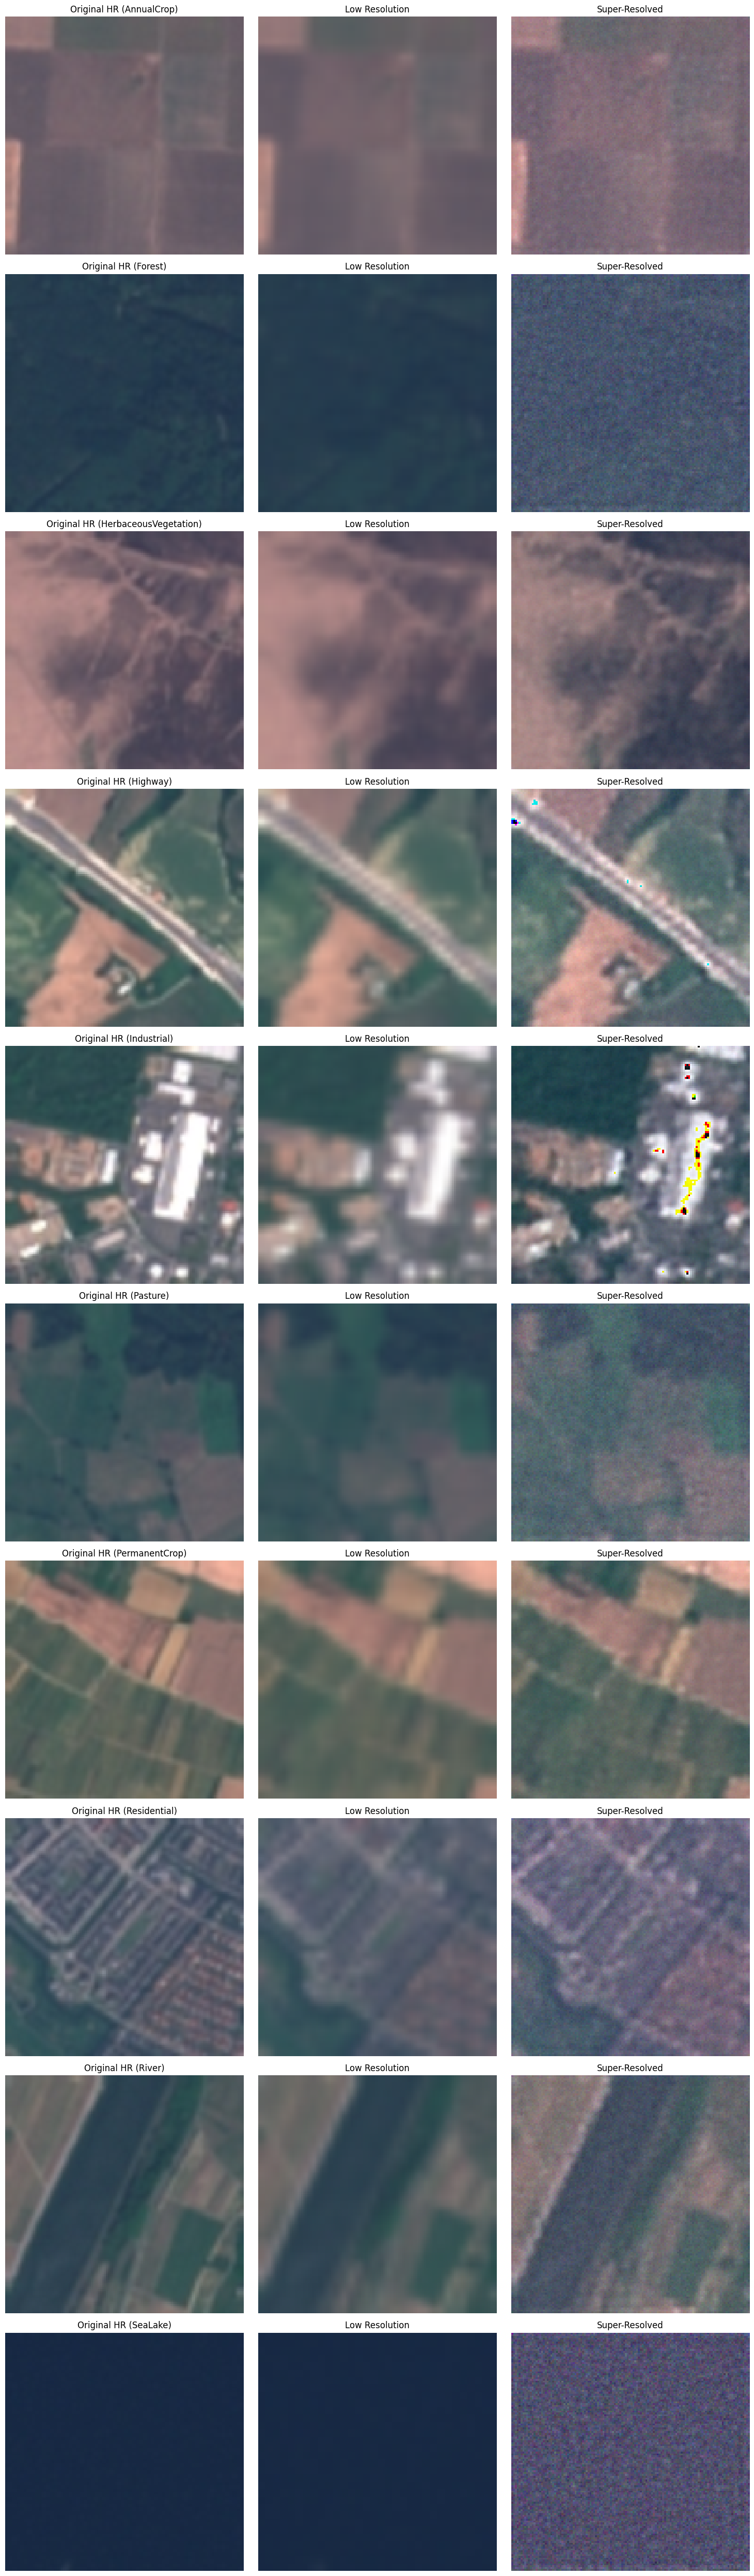

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

T = 500
betas = torch.linspace(1e-4, 0.02, T).to(device)
ddpm = DDPM(betas, device)

model = UNet(T).to(device)
model.load_state_dict(torch.load("/content/eurosat_sr_ddpm.pth", map_location=device))
model.eval()
data_files = {"train_split": "/kaggle/input/eurosat-dataset/EuroSAT/*/*.jpg"}
full_dataset = load_dataset("imagefolder", data_files=data_files)["train_split"]

temp_dataset_instance = EuroSAT_SR_Dataset(full_dataset)
hr_tf = temp_dataset_instance.hr_tf
lr_tf = temp_dataset_instance.lr_tf

all_categories = set()
print("Identifying all unique image categories...")
for i in tqdm(range(len(full_dataset)), desc="Processing dataset for categories"):
    sample_item = full_dataset[i]
    label_id = sample_item["label"]
    category_name = full_dataset.features["label"].int2str(label_id)
    all_categories.add(category_name)

print(f"All unique categories identified: {sorted(list(all_categories))}")
print(f"Total unique categories: {len(all_categories)}\n")


collected_categories = set()
sample_data = [] # Initialize sample_data list

print(f"Collecting one sample image from each of the {len(all_categories)} categories...")
for sample in tqdm(full_dataset, desc="Collecting samples"):
    img = sample["image"].convert("RGB")
    label_id = sample["label"]
    category_name = full_dataset.features["label"].int2str(label_id)

    if category_name not in collected_categories:
        collected_categories.add(category_name)
        sample_data.append({"image": img, "category": category_name})
        if len(sample_data) == len(all_categories):
            break

print(f"Collected {len(sample_data)} images, one from each unique category.")

num_categories_to_plot = len(sample_data)
plt.figure(figsize=(15, num_categories_to_plot * 5))

for i, data_item in enumerate(sample_data):
    img = data_item["image"]
    category_name = data_item["category"]

    hr_img_tensor = hr_tf(img).unsqueeze(0).to(device)
    lr_img_tensor = lr_tf(img).unsqueeze(0).to(device)

    x_t = torch.randn_like(hr_img_tensor).to(device)

    with torch.no_grad():
        for t in tqdm(reversed(range(T)), desc=f"Sampling image {i+1} ({category_name})"):
            ts = torch.full((1,), t, device=device, dtype=torch.long)
            model_input = torch.cat([x_t, lr_img_tensor], dim=1)
            eps_theta = model(model_input, ts)
            x_t = ddpm.reverse_q(x_t, ts, eps_theta)

    hr_display = (hr_img_tensor.squeeze(0).cpu() + 1) * 0.5
    lr_display = (lr_img_tensor.squeeze(0).cpu() + 1) * 0.5
    sr_display = (x_t.squeeze(0).cpu() + 1) * 0.5

    hr_pil = transforms.ToPILImage()(hr_display)
    lr_pil = transforms.ToPILImage()(lr_display)
    sr_pil = transforms.ToPILImage()(sr_display)

    plt.subplot(num_categories_to_plot, 3, i * 3 + 1)
    plt.imshow(hr_pil)
    plt.title(f"Original HR ({category_name})")
    plt.axis("off")

    plt.subplot(num_categories_to_plot, 3, i * 3 + 2)
    plt.imshow(lr_pil)
    plt.title("Low Resolution")
    plt.axis("off")

    plt.subplot(num_categories_to_plot, 3, i * 3 + 3)
    plt.imshow(sr_pil)
    plt.title("Super-Resolved")
    plt.axis("off")

plt.tight_layout()
plt.show()